Group 11 : SMART WASTE PREDICTION SYSTEM
Members;
19/03455 Sadia Galm
23/02196 Gitaka Kevin
23/04126 Zeyruq Abdullahi

# PART 1: Import of libs

In [30]:
import pandas as pd # data analysis and manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns  # for better enhanced charts
import folium  # creates interactive maps


from sklearn.model_selection import train_test_split  # splits data into training and testing sets
from sklearn.ensemble import RandomForestRegressor # one of the ML algorithms we chose, the building of many decision trees and averaging their results
                                                   # makes it more accurate
from sklearn.cluster import KMeans # used for grouping of waste bins based on geographic location and fill level
from sklearn.preprocessing import StandardScaler, OneHotEncoder # SS standardizes numerical data into a standard scale, helps the model to treat all 
                                                                # features equally, esp units such as kg,% etc
                                                                # OHE converts categorical text data, such as days of the week, into a numerical format 
                                                                # that the model can understand
from sklearn.compose import ColumnTransformer # will allow for scaling different columns, eg, temp, humidity, and categorical columns like the days of 
                                              # the week together in one step b4 training
from sklearn.pipeline import Pipeline # creates a chain/pipeline of all modelling steps that, when we fit and predict, everything else 
                                       # (scaling, encoding, and model training) is done together in one go and automatically
from sklearn.metrics import mean_squared_error, r2_score # measures the model's performance
from sklearn.impute import SimpleImputer

# PART 2: Loading the datasets

In [10]:
# Kaggle dataset
bins = pd.read_csv('Smart_Bin.csv')
print("SMART BIN DATASET(KAGGLE)")
display(bins.head())

#Open Data
kenya = pd.read_csv('waste-management-status-in-major-towns-of-kenya.csv')
print("\nKENYA WASTE MGT DATASET(OPENDATA")
display(kenya.head())

SMART BIN DATASET(KAGGLE)


,Class,FL_B,FL_A,VS,FL_B_3,FL_A_3,FL_B_12,FL_A_12,Container Type,Recyclable fraction
0,Emptying,85.3,34.4,6.0,75.9,54.7,83.3,39.8,Silvertop-a,Mixed
1,Emptying,96.2,51.7,8.0,83.3,33.9,85.0,57.4,BIM-3 FTI bottentomd,Non Recyclable
2,Non Emptying,50.9,63.5,5.0,30.8,55.7,51.7,68.5,BIM-3 FTI bottentomd,Recyclable
3,Emptying,83.1,33.9,6.0,91.8,61.1,84.6,43.6,Lindstrom-a,Mixed
4,Non Emptying,73.5,32.2,3.0,68.0,30.5,62.4,53.0,Lindstrom-a,Non Recyclable



KENYA WASTE MGT DATASET(OPENDATA


,Unnamed: 0,Estimated Waste generated (tons/day),Waste collected,Waste Recovery,Uncollected waste
0,Nairobi,2400,80,45,20
1,Nakuru,250,45,18,37
2,Kisumu,400,20,Unknown,Unknown
3,Thika,140,60,30,40
4,Mombasa,2200,65,40,35


# PART 3: Cleaning the data and feature preparation

In [12]:
print(bins.columns.tolist())

# so currently we have fill-level data spread out accross multiple columns
# Combine multiple fill-level columns into one average column as the model expects
fill_cols = ['FL_A', 'FL_B', 'FL_A_3', 'FL_B_3', 'FL_A_12', 'FL_B_12']

# Check if they all exist in your dataset before using
fill_cols = [col for col in fill_cols if col in bins.columns]

# Create the unified fill_level column
bins['fill_level'] = bins[fill_cols].mean(axis=1)

# Preview new column
print(bins[['fill_level']].head())


['Class', 'FL_B', 'FL_A', 'VS', 'FL_B_3', 'FL_A_3', 'FL_B_12', 'FL_A_12', 'Container Type', 'Recyclable fraction']
   fill_level
0   62.233333
1   67.916667
2   53.516667
3   66.350000
4   53.266667


In [37]:
# we first check for duplicates and missing values in the datasets
print("Duplicate rows are:", bins.duplicated().sum())
print("\nMissing values per column are:\n", bins.isnull().sum())

# drop these rows
bins= bins.drop_duplicates()
bins.dropna(subset=['fill_level'], inplace=True)


# so a timestamp is important in making the model to predict fill levels more accurately, since waste generation varies by the time of day
#and day of the week, so we check for a timestamp and if there isnt one we create it

# Convert timestamp (if present) to datetime for time-based features
if 'timestamp' in bins.columns:
    bins['timestamp'] = pd.to_datetime(bins['timestamp'])
    bins['hour'] = bins['timestamp'].dt.hour
    bins['day'] = bins['timestamp'].dt.day_name()
else:
    # If timestamp doesn't exist, create simulated time features
    bins['hour'] = np.random.randint(0, 24, len(bins))
    bins['day'] = np.random.choice(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], len(bins))

# View summary after cleaning
print("\nCleaned Dataset Sample:")
display(bins.head())


Duplicate rows are: 0

Missing values per column are:
 Class                  0
FL_B                   2
FL_A                   0
VS                     7
FL_B_3                 0
FL_A_3                 4
FL_B_12                5
FL_A_12                0
Container Type         0
Recyclable fraction    0
fill_level             0
hour                   0
day                    0
dtype: int64

Cleaned Dataset Sample:


,Class,FL_B,FL_A,VS,FL_B_3,FL_A_3,FL_B_12,FL_A_12,Container Type,Recyclable fraction,fill_level,hour,day
0,Emptying,85.3,34.4,6.0,75.9,54.7,83.3,39.8,Silvertop-a,Mixed,62.233333,22,Mon
1,Emptying,96.2,51.7,8.0,83.3,33.9,85.0,57.4,BIM-3 FTI bottentomd,Non Recyclable,67.916667,1,Thu
2,Non Emptying,50.9,63.5,5.0,30.8,55.7,51.7,68.5,BIM-3 FTI bottentomd,Recyclable,53.516667,7,Wed
3,Emptying,83.1,33.9,6.0,91.8,61.1,84.6,43.6,Lindstrom-a,Mixed,66.350000,7,Wed
4,Non Emptying,73.5,32.2,3.0,68.0,30.5,62.4,53.0,Lindstrom-a,Non Recyclable,53.266667,8,Mon


# PART 4: Feature selection and model training

In [35]:
# ==============================================================
# STEP: Train Random Forest Model for Bin Fill Level Prediction
# ==============================================================

# 1️⃣ Choose features based on data types
numeric_features = ['FL_A', 'FL_B', 'VS']  # purely numeric sensor readings
categorical_features = ['Container Type', 'Class', 'Recyclable fraction']  # text columns

target = 'fill_level'
features = numeric_features + categorical_features

# 2️⃣ Split dataset into features (X) and target (y)
X = bins[features]
y = bins[target]

# 3️⃣ Preprocessing pipeline with imputation for missing values
preprocessor = ColumnTransformer([
    # Add SimpleImputer to handle missing values in numeric features
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),  # Replace NaN with mean
        ('scaler', StandardScaler())
    ]), numeric_features),
    
    # Add SimpleImputer with 'most_frequent' strategy for categorical features
    ('category', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  # Replace NaN with most frequent value
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

# 4️⃣ Split data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Build the Random Forest model pipeline
RFM = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# Train the model
RFM.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print("Model Evaluation:")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Model Evaluation:
Root Mean Squared Error (RMSE): 5.92
R² Score: 0.58


# Visualizing the predictions

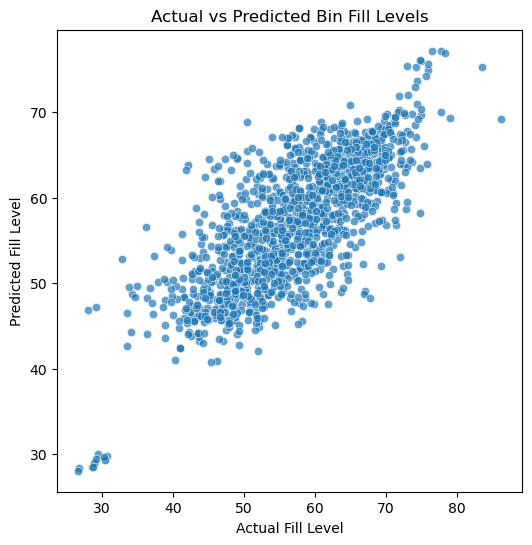

In [39]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel('Actual Fill Level')
plt.ylabel('Predicted Fill Level')
plt.title('Actual vs Predicted Bin Fill Levels')
plt.show()


# PART 5: Route Optimization (KMeans)

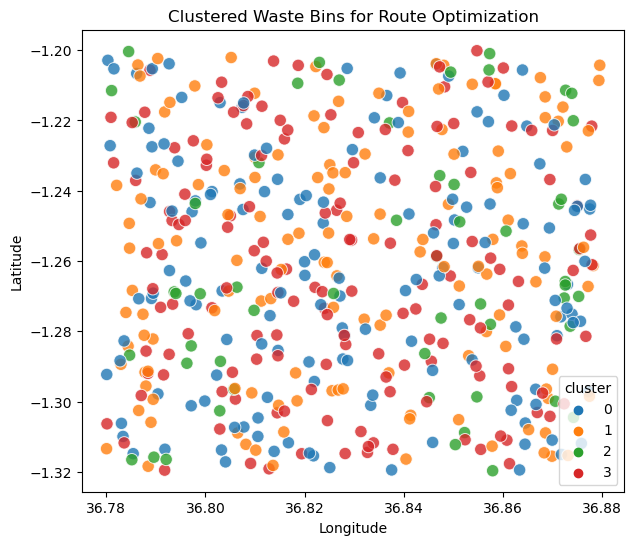

In [56]:
# Ensured we have location data; if not, simulate approximate Nairobi coordinates
if 'latitude' not in bins.columns or 'longitude' not in bins.columns:
    bins['latitude'] = np.random.uniform(-1.320, -1.200, len(bins))
    bins['longitude'] = np.random.uniform(36.780, 36.880, len(bins))

# Use predicted fill levels for more realistic clustering
bins['predicted_fill'] = model.predict(X)

# Select relevant features for clustering
cluster_data = bins[['latitude', 'longitude', 'predicted_fill']]

# Apply K-Means (4 clusters for example)
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
bins['cluster'] = kmeans.fit_predict(cluster_data)

# Visualize clusters
plt.figure(figsize=(7,6))
sns.scatterplot(data=bins.sample(500), x='longitude', y='latitude', hue='cluster', palette='tab10', s=80, alpha=0.8)
plt.title('Clustered Waste Bins for Route Optimization')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [60]:
# creation of an interactive map

import folium

# create the map centered on Nairobi
nairobi_map = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# define colors for different zones
zone_colors = {
    'CBD': 'red',
    'Westlands': 'blue',
    'Eastlands': 'green',
    'South B / Industrial Area': 'orange'
}

# plot bins by zone
for _, row in bins.iterrows():
    zone = row['zone']
    color = zone_colors.get(zone, 'gray')
    popup_info = (f"<b>Zone:</b> {zone}<br>"
                  f"<b>Predicted Fill Level:</b> {row['predicted_fill']:.1f}%<br>"
                  f"<b>Coordinates:</b> ({row['latitude']:.4f}, {row['longitude']:.4f})")
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup_info, max_width=250)
    ).add_to(nairobi_map)

# add cluster centers (route starting points)
centers = kmeans.cluster_centers_

for i, (lat, lon, _) in enumerate(centers):
    zone = zone_names.get(i, f"Zone {i}")
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>{zone}</b>",
        icon=folium.Icon(color='darkpurple', icon='truck', prefix='fa')
    ).add_to(nairobi_map)

# Step 5: Display map
nairobi_map


